## Introduction

In this project, we will be taking data from the 1994 Census database in order to create a logistic regression model that will predict whether or not a person makes more than $50,000

### Logistic Regression Model

A `Logistic Regression Model` is a statistical method used for binary classification tasks (where the outcome variable has only two possible values, typically labeled as 0 and 1).

This model predicts the probability that a given input belongs to one of these categories, and achieves this by using the `logistic (sigmoid) function`, which compresses predicted values into a range between 0 and 1.

Unlike linear regression, which predicts continuous outcomes, logistic regression works with a log-odds transformation of probabilities, enabling it to handle classification problems effectively.

Some of the advantages in using a Logistic Regression model are:

- `Simplicity and Interpretability:` This model is easy to implement and interpret; the model's coefficients tell you how much each input feature contributes to the probability of the outcome.
- `Efficiency:` The model requires relatively fewer computational resources and works well on smaller datasets.
- `Probabilistic Output:` The model predicts probabilities, allowing you to set custom decision thresholds based on specific needs.
- `Feature Importance:` Coefficients of the model provide insights into the relative importance of features.

## Data and Pre-Analysis

Our dataset comes from the UCI Machine Learning Repository and contains the following features:

- `age`: Age of the person
- `workclass`: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked
- `fnlwgt`: N/A
- `education`: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool
- `education-num`: N/A
- `marital-status`: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse
- `occupation`: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces
- `relationship`: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried
- `race`: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black
- `sex`: Female, Male
- `capital-gain`: N/A
- `capital-loss`: N/A
- `hours-per-week`: Hours worked per week
- `native-country`: Various countires
- `income`: >50K, <=50K

### Installing All Necessary Packages and Modules

As usual, the first thing that we need to do before anything else is to install all of the necessary packages and modules into our vitual environment.

In [ ]:
# Installing necessary packages into virtual environment
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

In [2]:
# Import necessary modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score 
from sklearn.preprocessing import StandardScaler

%matplotlib inline

### Loading in the Data

Before we can begin our data preparation and analysis, we first must load our data file into a Pandas DataFrame.

In addition to this, we will define a list of column names to assign to the DataFrame. The column names will be the equivalent names of those referened in the `Data` section.

In [3]:
# Defining column names
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
             'marital-status', 'occupation', 'relationship', 'race', 'sex', 
             'capital-gain', 'capital-loss', 'hours-per-week', 
             'native-country', 'income']

# Creating Pandas DataFrame
df = pd.read_csv('adult.data', header = None, names = col_names)

The next thing that we want to do is make sure that we strip all of the extra whitespace from any columns that have a data type of `object`, just to ensure that we do not run into any problems due to this whitespace further on in our analysis.

In [4]:
# Stripping extra whitespace in "object" columns
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

# Displaying DataFrame
print(df.head())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

With these inital data preparation steps completed, we are now able to being further analysis.

## Analysis

### Balancing the Dataset

The first thing that we want to do with our dataset is to check and see if it is balanced.

The reason for doing this is, due to the fact that we will be implementing a Logistic Regression model, we need to ensure that our dataset is balanced so that our model performs well, and does not make biased predictions due to one class being weighed more heavily than another.

In [5]:
# Checking to see if classes are imbalanced
print(df.income.value_counts(normalize=True))

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


### Defining the Predictor (Independent) Variables

Next, we need to define which columns will be the feature columns, or predictor variables for our model.

We will do so in a list, `feature_cols`.

In addition to this, we will also create dummy variables for our categorical data features, to ensure that when we are making predictions with our model, we can establish a baseline and explicitly know which categorical fatures have a strong correlation to predicting income.

In [6]:
# Creating feature_cols
feature_cols = ['age', 'capital-gain', 'capital-loss', 
                'hours-per-week', 'sex', 'race', 'education']

# Creating dummy variables
X = pd.get_dummies(df[feature_cols], drop_first=True)

### Investigating Feature Correlation with a Heatmap

The next thing that we are going to do that incorporates more EDA into our intial analysis, is we are going to create a heatmap of our `X` data just to see if we can pick up on any initial feature correlation.

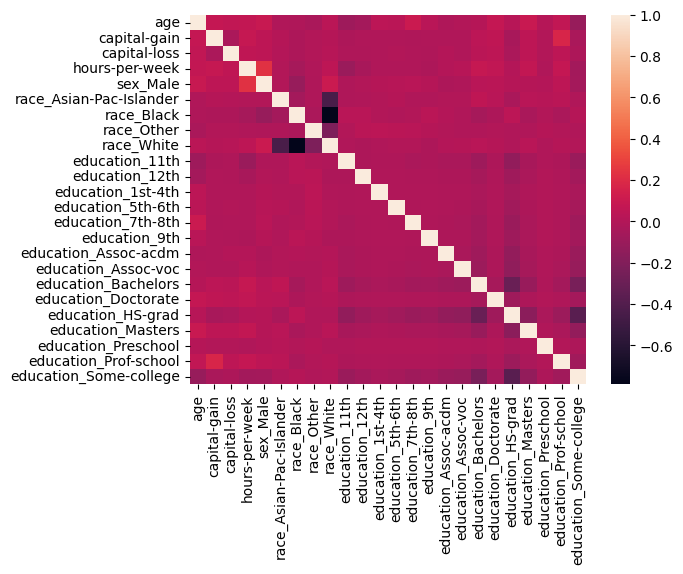

In [7]:
# Creating a heatmap of X data
plt.figure()
sns.heatmap(X.corr())
plt.show()
plt.close()

### Defining the Outcome (Dependent) Variable

Now that we have our initial analysis completed, the last thing that we need to do before beginning to implement our model is to create our y (dependent) variable.

To do this, we will create variable, `y`, which will be binary.

The values will be `0` when income is less than $50K, and `1` when income is greater than $50K.

In [8]:
# Creating variable y
y = np.where(df.income=='<=50K', 0, 1)

### Splitting the Data into Training and Testing Sets

Now we are ready to begin splitting our data into our testing and training sets.

For this instance, the `random_state` will be set to 1, and `test_size` will be set to .2.

In [9]:
# Splitting data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=1, test_size=.2)

### Defining, Fitting, and Predicting with the Logistic Regression Model

Now that our data has been split into training and testing sets, we can fit our data to a Logistic Regression model.

In this instance, we will be setting the arguments `C` = 0.05, `penalty` = l1, and `solver` = liblinear.

In additon to this, we will also use `.predict()` to create the predictions for our `y` variable.

In [10]:
# Defining and fitting Logistic Regression model
log_reg = LogisticRegression(C=0.05, 
                             penalty='l1', 
                             solver='liblinear')
log_reg.fit(x_train, y_train)

# Predicting the test set
y_pred = log_reg.predict(x_test)

### Investigating Model Parameters

Next, we will display our model parameters.

Intercept and Coefficients.

In [11]:
# Printing Intercept
print("Model Parameters, Intercept:")
print(log_reg.intercept_[0])
print("Model Parameters, Coeff:")
print(log_reg.coef_)

Model Parameters, Intercept:
-5.631316275939536
Model Parameters, Coeff:
[[ 3.69612041e-02  3.14964400e-04  6.66736042e-04  3.23043602e-02
   1.03337755e+00  0.00000000e+00 -3.31914074e-01  0.00000000e+00
   1.02904945e-01 -5.72758751e-01  0.00000000e+00  0.00000000e+00
  -3.99204179e-01 -8.97299923e-01 -5.00339608e-01  5.75444190e-01
   5.49793436e-01  1.28598078e+00  1.80104909e+00  0.00000000e+00
   1.60180302e+00  0.00000000e+00  1.82631292e+00  3.87882115e-01]]


### Evaluating the Predictions using the Testing Dataset

Now that we have made our predictions, we can evaluate these predictions on our testing dataset.

To evaluate, we will be displaying a confusion matirx and accuracy score of our model application on our testing dataset.

In [12]:
# Printing confusion matrix
print("Confusion Matrix on test set:")
print(confusion_matrix(y_test, y_pred))

# Printing accuracy score
print(f"Accuracy Score on test set: {log_reg.score(x_test, y_test)}")

Confusion Matrix on test set:
[[4773  253]
 [ 880  607]]
Accuracy Score on test set: 0.826040227237832


Here, we can see that our model has an accuracy score of about 83%, which is not too bad at all.

### Updating the DataFrame

Next, we want to create a new DataFrame that will consist of our model coefficients with their corresponding variable names, and we will sort this data frame based on the values of the coefficients.

This is done in preparation so that we can graphically model the variables and their effect on the output, `y`.

In [13]:
# Creating and sorting new DataFrame
coef_df = pd.DataFrame(zip(x_train.columns, 
                           log_reg.coef_[0]), 
                           columns=['var', 'coef']).sort_values('coef')

# Printing DataFrame
print(coef_df)

                        var      coef
13        education_7th-8th -0.897300
9            education_11th -0.572759
14            education_9th -0.500340
12        education_5th-6th -0.399204
6                race_Black -0.331914
11        education_1st-4th  0.000000
21      education_Preschool  0.000000
5   race_Asian-Pac-Islander  0.000000
7                race_Other  0.000000
19        education_HS-grad  0.000000
10           education_12th  0.000000
1              capital-gain  0.000315
2              capital-loss  0.000667
3            hours-per-week  0.032304
0                       age  0.036961
8                race_White  0.102905
23   education_Some-college  0.387882
16      education_Assoc-voc  0.549793
15     education_Assoc-acdm  0.575444
4                  sex_Male  1.033378
17      education_Bachelors  1.285981
20        education_Masters  1.601803
18      education_Doctorate  1.801049
22    education_Prof-school  1.826313


### Visualizing the Results

Now, we can visually display our new DataFrame in a bar plot, which we will sort in ascending order.

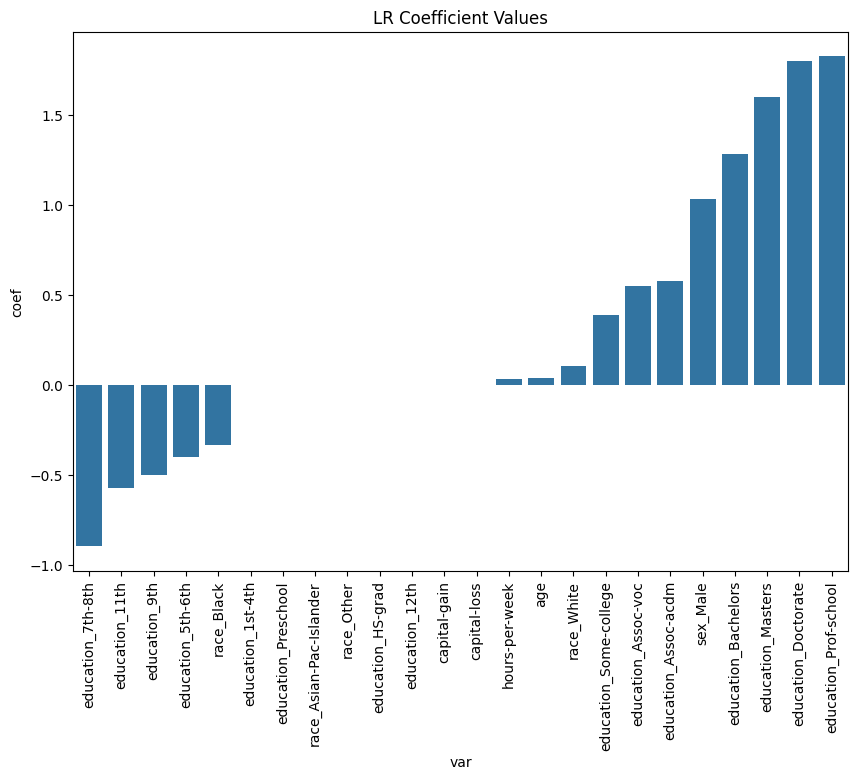

In [14]:
# Creating bar plot of our new DataFrame
plt.figure(figsize=(10,7))
sns.barplot(data=coef_df, x='var', y='coef')
plt.xticks(rotation=90)
plt.title("LR Coefficient Values")
plt.show()
plt.close()

### ROC Curve and AUC Value

The last thing that we want to do before completing our analysis is to define and plot the ROC curve and the AUC value.

The ROC (Reciever Operating Characteristic) curve is used to evaluate the performance of a binary classification model. This curve illustrates the trade-off between the sensitivity (true positive rate) and the specificity (false positive rate) across different threshold values.

The Area Under the Curve (AUC) of the ROC curve quantifies the overall ability of the model to discriminate between positive and negative classes. This value is measured from 0-1 and ideally, we would like a higher value rather than lower.

ROC AUC score: 0.8457338584485088


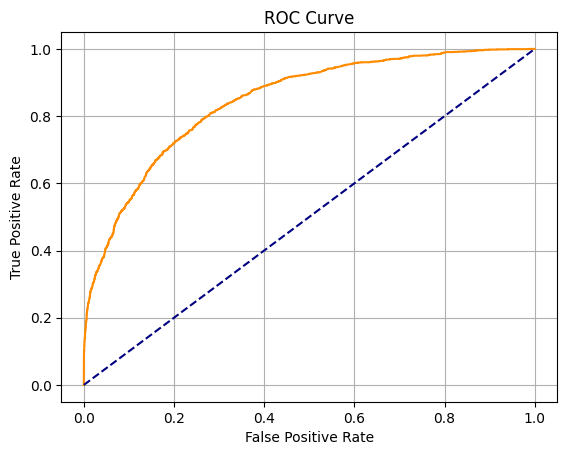

In [16]:
# Plotting ROC and printing AUC value
y_pred_prob = log_reg.predict_proba(x_test)
roc_auc = roc_auc_score(y_test, y_pred_prob[:,1])
print(f"ROC AUC score: {roc_auc}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob[:,1])
plt.figure()
plt.plot(fpr, tpr, color='darkorange', 
         label='ROC curve (area = %0.2f)' % roc_auc)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0,1],[0,1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.grid()
plt.show()